In [1]:
"""
WorldQuant Alpha Implementation
Mean Reversion + Intraday Exhaustion + Volume Confirmation

Formula:
rank(
    (
        (-1 * (close/ts_delay(close,3) - 1) / ts_std_dev(close/ts_delay(close,1) - 1, 7))
        + 1.0 * (-1 * (2*close - high - low)/(high - low))
    )
    * rank(volume/adv20)
)

This notebook provides a complete implementation with:
- Data fetching (yfinance)
- Alpha calculation
- Backtesting framework
- Performance analysis
- Visualization
"""

# ============================================================================
# PART 1: IMPORTS AND SETUP
# ============================================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries imported successfully!")
print("=" * 80)

# ============================================================================
# PART 2: HELPER FUNCTIONS FOR TIME SERIES OPERATIONS
# ============================================================================

def ts_delay(df, column, period):
    """
    Time series delay - shift series back by period days
    
    Parameters:
    -----------
    df : DataFrame
    column : str - column name to delay
    period : int - number of periods to shift
    
    Returns:
    --------
    Series with delayed values
    """
    return df[column].shift(period)


def ts_std_dev(df, column, period):
    """
    Time series standard deviation - rolling standard deviation
    
    Parameters:
    -----------
    df : DataFrame
    column : str - column name
    period : int - lookback window
    
    Returns:
    --------
    Series with rolling standard deviation
    """
    return df[column].rolling(window=period, min_periods=period).std()


def rank_cross_sectional(df, column):
    """
    Cross-sectional ranking - rank values within each date
    Converts to percentile rank (0 to 1)
    
    Parameters:
    -----------
    df : DataFrame with MultiIndex (date, ticker)
    column : str - column to rank
    
    Returns:
    --------
    Series with percentile ranks
    """
    return df.groupby(level='date')[column].rank(pct=True)


def rank_single(series):
    """
    Rank a single series (for single stock analysis)
    
    Parameters:
    -----------
    series : Series to rank
    
    Returns:
    --------
    Series with percentile ranks
    """
    return series.rank(pct=True)


# ============================================================================
# PART 3: ALPHA CALCULATION FUNCTION
# ============================================================================

def calculate_alpha(df, cross_sectional=False):
    """
    Calculate the WorldQuant alpha signal
    
    Formula:
    rank(
        (
            (-1 * (close/ts_delay(close,3) - 1) / ts_std_dev(close/ts_delay(close,1) - 1, 7))
            + 1.0 * (-1 * (2*close - high - low)/(high - low))
        )
        * rank(volume/adv20)
    )
    
    Parameters:
    -----------
    df : DataFrame with columns [close, high, low, volume]
         For cross-sectional: MultiIndex (date, ticker)
         For single stock: DatetimeIndex
    cross_sectional : bool - whether to use cross-sectional ranking
    
    Returns:
    --------
    DataFrame with alpha signals and components
    """
    
    # Make a copy to avoid modifying original
    data = df.copy()
    
    # ========================================================================
    # COMPONENT 1: Volatility-Adjusted 3-Day Mean Reversion
    # ========================================================================
    
    # Calculate 3-day returns
    if cross_sectional:
        data['close_3d_ago'] = data.groupby(level='ticker')['close'].shift(3)
    else:
        data['close_3d_ago'] = data['close'].shift(3)
    
    data['returns_3d'] = data['close'] / data['close_3d_ago'] - 1
    
    # Calculate daily returns for volatility
    data['returns_daily'] = data['close'].pct_change()
    
    # Calculate 7-day volatility (standard deviation of daily returns)
    if cross_sectional:
        data['volatility_7d'] = data.groupby(level='ticker')['returns_daily'].rolling(
            window=7, min_periods=7
        ).std().reset_index(level=0, drop=True)
    else:
        data['volatility_7d'] = data['returns_daily'].rolling(window=7, min_periods=7).std()
    
    # Risk-adjusted 3-day signal (inverted for mean reversion)
    data['component_1'] = -1 * data['returns_3d'] / data['volatility_7d']
    
    # ========================================================================
    # COMPONENT 2: Intraday Close Location Value (CLV)
    # ========================================================================
    
    # CLV = (2*close - high - low) / (high - low)
    # Measures where close is within the day's range
    # Inverted to fade strength
    data['clv'] = (2 * data['close'] - data['high'] - data['low']) / (data['high'] - data['low'])
    data['component_2'] = -1 * data['clv']
    
    # ========================================================================
    # COMPONENT 3: Volume Confirmation
    # ========================================================================
    
    # Calculate 20-day average volume
    if cross_sectional:
        data['adv20'] = data.groupby(level='ticker')['volume'].rolling(
            window=20, min_periods=20
        ).mean().reset_index(level=0, drop=True)
    else:
        data['adv20'] = data['volume'].rolling(window=20, min_periods=20).mean()
    
    # Volume ratio
    data['volume_ratio'] = data['volume'] / data['adv20']
    
    # Rank volume ratio
    if cross_sectional:
        data['volume_rank'] = rank_cross_sectional(data, 'volume_ratio')
    else:
        data['volume_rank'] = rank_single(data['volume_ratio'])
    
    # ========================================================================
    # COMBINE COMPONENTS
    # ========================================================================
    
    # Combine multi-day and intraday signals (equal weight)
    data['combined_signal'] = data['component_1'] + 1.0 * data['component_2']
    
    # Weight by volume rank
    data['weighted_signal'] = data['combined_signal'] * data['volume_rank']
    
    # ========================================================================
    # FINAL ALPHA: Cross-sectional ranking
    # ========================================================================
    
    if cross_sectional:
        data['alpha'] = rank_cross_sectional(data, 'weighted_signal')
    else:
        data['alpha'] = rank_single(data['weighted_signal'])
    
    return data


# ============================================================================
# PART 4: DATA FETCHING
# ============================================================================

def fetch_stock_data(tickers, start_date, end_date):
    """
    Fetch historical stock data from Yahoo Finance
    
    Parameters:
    -----------
    tickers : list - ticker symbols
    start_date : str - start date 'YYYY-MM-DD'
    end_date : str - end date 'YYYY-MM-DD'
    
    Returns:
    --------
    DataFrame with MultiIndex (date, ticker) and columns [open, high, low, close, volume]
    """
    
    print(f"📥 Fetching data for {len(tickers)} stocks from {start_date} to {end_date}...")
    
    all_data = []
    
    for ticker in tickers:
        try:
            # Download data
            stock = yf.download(ticker, start=start_date, end=end_date, progress=False)
            
            if stock.empty:
                print(f"⚠️  No data for {ticker}")
                continue
            
            # Prepare data
            stock = stock[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
            stock.columns = ['open', 'high', 'low', 'close', 'volume']
            stock['ticker'] = ticker
            stock.reset_index(inplace=True)
            stock.rename(columns={'Date': 'date'}, inplace=True)
            
            all_data.append(stock)
            
        except Exception as e:
            print(f"❌ Error fetching {ticker}: {str(e)}")
            continue
    
    if not all_data:
        raise ValueError("No data fetched for any tickers!")
    
    # Combine all stocks
    combined = pd.concat(all_data, ignore_index=True)
    combined['date'] = pd.to_datetime(combined['date'])
    
    # Set MultiIndex
    combined.set_index(['date', 'ticker'], inplace=True)
    combined.sort_index(inplace=True)
    
    print(f"✅ Successfully fetched data for {len(combined.index.get_level_values('ticker').unique())} stocks")
    print(f"📅 Date range: {combined.index.get_level_values('date').min().date()} to {combined.index.get_level_values('date').max().date()}")
    print(f"📊 Total observations: {len(combined):,}")
    print()
    
    return combined


# ============================================================================
# PART 5: BACKTESTING FRAMEWORK
# ============================================================================

def backtest_alpha(df, holding_period=1, long_percentile=0.9, short_percentile=0.1):
    """
    Backtest the alpha strategy
    
    Parameters:
    -----------
    df : DataFrame with alpha signals (MultiIndex: date, ticker)
    holding_period : int - days to hold positions
    long_percentile : float - percentile threshold for long positions (e.g., 0.9 = top 10%)
    short_percentile : float - percentile threshold for short positions (e.g., 0.1 = bottom 10%)
    
    Returns:
    --------
    DataFrame with daily portfolio returns and statistics
    """
    
    print(f"🔄 Running backtest...")
    print(f"   Long threshold: top {(1-long_percentile)*100:.0f}% (alpha >= {long_percentile})")
    print(f"   Short threshold: bottom {short_percentile*100:.0f}% (alpha <= {short_percentile})")
    print(f"   Holding period: {holding_period} day(s)")
    print()
    
    # Calculate forward returns
    df = df.copy()
    df['forward_return'] = df.groupby(level='ticker')['close'].pct_change(holding_period).shift(-holding_period)
    
    # Identify positions
    df['position'] = 0
    df.loc[df['alpha'] >= long_percentile, 'position'] = 1  # Long
    df.loc[df['alpha'] <= short_percentile, 'position'] = -1  # Short
    
    # Calculate position returns
    df['position_return'] = df['position'] * df['forward_return']
    
    # Aggregate to daily portfolio returns
    daily_returns = df.groupby(level='date').agg({
        'position_return': 'mean',
        'position': ['sum', 'count'],
        'alpha': ['mean', 'std']
    }).dropna()
    
    daily_returns.columns = ['portfolio_return', 'net_positions', 'total_positions', 'avg_alpha', 'alpha_std']
    
    # Calculate cumulative returns
    daily_returns['cumulative_return'] = (1 + daily_returns['portfolio_return']).cumprod() - 1
    
    # Calculate drawdown
    cumulative = (1 + daily_returns['portfolio_return']).cumprod()
    running_max = cumulative.expanding().max()
    daily_returns['drawdown'] = (cumulative - running_max) / running_max
    
    return daily_returns


def calculate_performance_metrics(daily_returns):
    """
    Calculate performance metrics from backtest results
    
    Parameters:
    -----------
    daily_returns : DataFrame from backtest_alpha()
    
    Returns:
    --------
    Dictionary of performance metrics
    """
    
    returns = daily_returns['portfolio_return'].dropna()
    
    if len(returns) == 0:
        return {}
    
    # Annualization factor (assuming 252 trading days)
    annual_factor = 252
    
    # Calculate metrics
    total_return = (1 + returns).prod() - 1
    annual_return = (1 + total_return) ** (annual_factor / len(returns)) - 1
    annual_vol = returns.std() * np.sqrt(annual_factor)
    sharpe_ratio = annual_return / annual_vol if annual_vol > 0 else 0
    
    max_drawdown = daily_returns['drawdown'].min()
    
    # Win rate
    win_rate = (returns > 0).sum() / len(returns)
    
    # Average position counts
    avg_long = (daily_returns['net_positions'] > 0).sum() / len(daily_returns)
    avg_short = (daily_returns['net_positions'] < 0).sum() / len(daily_returns)
    
    metrics = {
        'Total Return': f"{total_return*100:.2f}%",
        'Annual Return': f"{annual_return*100:.2f}%",
        'Annual Volatility': f"{annual_vol*100:.2f}%",
        'Sharpe Ratio': f"{sharpe_ratio:.2f}",
        'Max Drawdown': f"{max_drawdown*100:.2f}%",
        'Win Rate': f"{win_rate*100:.2f}%",
        'Total Days': len(returns),
        'Avg Daily Return': f"{returns.mean()*100:.4f}%",
        '% Days Long Bias': f"{avg_long*100:.1f}%",
        '% Days Short Bias': f"{avg_short*100:.1f}%"
    }
    
    return metrics


# ============================================================================
# PART 6: VISUALIZATION FUNCTIONS
# ============================================================================

def plot_alpha_components(data, ticker=None, figsize=(16, 12)):
    """
    Plot alpha components for analysis
    
    Parameters:
    -----------
    data : DataFrame with alpha calculations
    ticker : str - specific ticker to plot (for multi-stock data)
    figsize : tuple - figure size
    """
    
    # Filter to specific ticker if cross-sectional
    if ticker and 'ticker' in data.index.names:
        plot_data = data.xs(ticker, level='ticker').copy()
        title_suffix = f" - {ticker}"
    else:
        plot_data = data.copy()
        title_suffix = ""
    
    fig, axes = plt.subplots(5, 1, figsize=figsize)
    fig.suptitle(f'Alpha Components Analysis{title_suffix}', fontsize=16, y=0.995)
    
    # Plot 1: Price
    axes[0].plot(plot_data.index.get_level_values('date') if 'date' in plot_data.index.names else plot_data.index, 
                 plot_data['close'], label='Close Price', color='black', linewidth=1.5)
    axes[0].set_title('Price')
    axes[0].set_ylabel('Price ($)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Component 1 (Multi-day mean reversion)
    axes[1].plot(plot_data.index.get_level_values('date') if 'date' in plot_data.index.names else plot_data.index,
                 plot_data['component_1'], label='Component 1: Vol-Adj 3D Reversion', color='blue', linewidth=1)
    axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[1].set_title('Component 1: Volatility-Adjusted 3-Day Mean Reversion')
    axes[1].set_ylabel('Signal')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Component 2 (Intraday)
    axes[2].plot(plot_data.index.get_level_values('date') if 'date' in plot_data.index.names else plot_data.index,
                 plot_data['component_2'], label='Component 2: Intraday CLV', color='green', linewidth=1)
    axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[2].set_title('Component 2: Intraday Close Location (Inverted)')
    axes[2].set_ylabel('Signal')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # Plot 4: Volume Rank
    axes[3].plot(plot_data.index.get_level_values('date') if 'date' in plot_data.index.names else plot_data.index,
                 plot_data['volume_rank'], label='Volume Rank', color='orange', linewidth=1)
    axes[3].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    axes[3].set_title('Volume Rank (relative to ADV20)')
    axes[3].set_ylabel('Rank')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
    
    # Plot 5: Final Alpha
    axes[4].plot(plot_data.index.get_level_values('date') if 'date' in plot_data.index.names else plot_data.index,
                 plot_data['alpha'], label='Final Alpha', color='purple', linewidth=1.5)
    axes[4].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    axes[4].axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Long Threshold')
    axes[4].axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Short Threshold')
    axes[4].set_title('Final Alpha Signal (Cross-Sectional Rank)')
    axes[4].set_ylabel('Alpha Rank')
    axes[4].set_xlabel('Date')
    axes[4].legend()
    axes[4].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_backtest_results(daily_returns, figsize=(16, 10)):
    """
    Plot backtest results
    
    Parameters:
    -----------
    daily_returns : DataFrame from backtest_alpha()
    figsize : tuple - figure size
    """
    
    fig, axes = plt.subplots(3, 1, figsize=figsize)
    fig.suptitle('Backtest Results', fontsize=16, y=0.995)
    
    # Plot 1: Cumulative Returns
    axes[0].plot(daily_returns.index, daily_returns['cumulative_return'] * 100, 
                 label='Strategy', color='blue', linewidth=2)
    axes[0].set_title('Cumulative Returns')
    axes[0].set_ylabel('Return (%)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Drawdown
    axes[1].fill_between(daily_returns.index, daily_returns['drawdown'] * 100, 0, 
                         color='red', alpha=0.3, label='Drawdown')
    axes[1].set_title('Drawdown')
    axes[1].set_ylabel('Drawdown (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Position Distribution
    axes[2].bar(daily_returns.index, daily_returns['net_positions'], 
                color='green', alpha=0.5, label='Net Positions')
    axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[2].set_title('Net Position Count (Long - Short)')
    axes[2].set_ylabel('Net Positions')
    axes[2].set_xlabel('Date')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ============================================================================
# PART 7: MAIN EXECUTION EXAMPLES
# ============================================================================

def example_single_stock():
    """
    Example: Calculate alpha for a single stock
    """
    
    print("=" * 80)
    print("EXAMPLE 1: SINGLE STOCK ANALYSIS")
    print("=" * 80)
    print()
    
    # Fetch data for Apple
    ticker = 'AAPL'
    end_date = datetime.now()
    start_date = end_date - timedelta(days=365)
    
    print(f"Analyzing {ticker}...")
    stock_data = yf.download(ticker, 
                             start=start_date.strftime('%Y-%m-%d'),
                             end=end_date.strftime('%Y-%m-%d'),
                             progress=False)
    
    # Prepare data
    stock_data = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    stock_data.columns = ['open', 'high', 'low', 'close', 'volume']
    
    print(f"✅ Fetched {len(stock_data)} days of data")
    print()
    
    # Calculate alpha
    result = calculate_alpha(stock_data, cross_sectional=False)
    
    # Display results
    print("📊 Alpha Signal Summary:")
    print("-" * 80)
    print(result[['close', 'component_1', 'component_2', 'volume_rank', 'alpha']].tail(10))
    print()
    
    print("📈 Recent Alpha Statistics:")
    print("-" * 80)
    print(f"Mean Alpha: {result['alpha'].mean():.3f}")
    print(f"Std Alpha: {result['alpha'].std():.3f}")
    print(f"Current Alpha: {result['alpha'].iloc[-1]:.3f}")
    print(f"Max Alpha: {result['alpha'].max():.3f}")
    print(f"Min Alpha: {result['alpha'].min():.3f}")
    print()
    
    # Plot components
    plot_alpha_components(result)
    
    return result


def example_multiple_stocks():
    """
    Example: Calculate alpha for multiple stocks (portfolio)
    """
    
    print("=" * 80)
    print("EXAMPLE 2: MULTI-STOCK PORTFOLIO ANALYSIS")
    print("=" * 80)
    print()
    
    # Define stock universe (you can modify this)
    tickers = [
        'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META',  # Tech
        'JPM', 'BAC', 'WFC', 'GS', 'MS',          # Financials
        'JNJ', 'UNH', 'PFE', 'ABBV', 'TMO',       # Healthcare
        'XOM', 'CVX', 'COP', 'SLB', 'EOG',        # Energy
        'WMT', 'HD', 'MCD', 'NKE', 'SBUX'         # Consumer
    ]
    
    # Fetch data
    end_date = datetime.now()
    start_date = end_date - timedelta(days=365)
    
    data = fetch_stock_data(tickers,
                           start_date.strftime('%Y-%m-%d'),
                           end_date.strftime('%Y-%m-%d'))
    
    # Calculate alpha
    print("🧮 Calculating alpha signals...")
    result = calculate_alpha(data, cross_sectional=True)
    print("✅ Alpha calculation complete!")
    print()
    
    # Display sample
    print("📊 Sample Alpha Signals (latest date):")
    print("-" * 80)
    latest_date = result.index.get_level_values('date').max()
    sample = result.xs(latest_date, level='date')[['close', 'alpha']].sort_values('alpha', ascending=False)
    print(sample.head(10))
    print()
    
    # Backtest
    backtest_results = backtest_alpha(result, holding_period=1, long_percentile=0.9, short_percentile=0.1)
    
    # Performance metrics
    metrics = calculate_performance_metrics(backtest_results)
    
    print("📈 BACKTEST PERFORMANCE:")
    print("=" * 80)
    for key, value in metrics.items():
        print(f"{key:.<30} {value:>20}")
    print()
    
    # Plot results
    plot_backtest_results(backtest_results)
    
    # Plot components for a specific stock
    print("📊 Plotting component analysis for AAPL...")
    plot_alpha_components(result, ticker='AAPL')
    
    return result, backtest_results


# ============================================================================
# PART 8: QUICK START TEMPLATES
# ============================================================================

def quick_start_single_stock(ticker, days=365):
    """
    Quick start: Analyze a single stock
    
    Parameters:
    -----------
    ticker : str - stock ticker symbol
    days : int - lookback period in days
    
    Returns:
    --------
    DataFrame with alpha signals
    """
    
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days)
    
    # Fetch data
    stock_data = yf.download(ticker, 
                             start=start_date.strftime('%Y-%m-%d'),
                             end=end_date.strftime('%Y-%m-%d'),
                             progress=False)
    
    stock_data = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    stock_data.columns = ['open', 'high', 'low', 'close', 'volume']
    
    # Calculate alpha
    result = calculate_alpha(stock_data, cross_sectional=False)
    
    # Display summary
    print(f"\n🎯 Alpha Signal for {ticker}")
    print(f"Current Alpha: {result['alpha'].iloc[-1]:.3f}")
    print(f"Signal: {'🟢 BUY' if result['alpha'].iloc[-1] > 0.7 else '🔴 SELL' if result['alpha'].iloc[-1] < 0.3 else '⚪ NEUTRAL'}")
    
    return result


def quick_start_portfolio(tickers, days=365):
    """
    Quick start: Analyze a portfolio
    
    Parameters:
    -----------
    tickers : list - list of ticker symbols
    days : int - lookback period in days
    
    Returns:
    --------
    DataFrame with alpha signals, DataFrame with backtest results
    """
    
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days)
    
    # Fetch data
    data = fetch_stock_data(tickers,
                           start_date.strftime('%Y-%m-%d'),
                           end_date.strftime('%Y-%m-%d'))
    
    # Calculate alpha
    result = calculate_alpha(data, cross_sectional=True)
    
    # Backtest
    backtest_results = backtest_alpha(result)
    
    # Performance
    metrics = calculate_performance_metrics(backtest_results)
    
    print("\n📈 PERFORMANCE SUMMARY:")
    print("=" * 50)
    for key, value in metrics.items():
        print(f"{key:.<30} {value:>15}")
    
    return result, backtest_results


# ============================================================================
# USAGE INSTRUCTIONS
# ============================================================================

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                   WORLDQUANT ALPHA IMPLEMENTATION                            ║
║                   Ready to Use - Choose Your Method                          ║
╚══════════════════════════════════════════════════════════════════════════════╝

📋 QUICK START OPTIONS:

1️⃣  SINGLE STOCK ANALYSIS:
   
   result = quick_start_single_stock('AAPL', days=365)
   plot_alpha_components(result)

2️⃣  PORTFOLIO ANALYSIS:
   
   tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
   result, backtest = quick_start_portfolio(tickers, days=365)
   plot_backtest_results(backtest)

3️⃣  DETAILED EXAMPLES:
   
   # Single stock with full analysis
   result = example_single_stock()
   
   # Multi-stock with backtesting
   result, backtest = example_multiple_stocks()

4️⃣  CUSTOM ANALYSIS:
   
   # Fetch your own data
   data = fetch_stock_data(['AAPL', 'MSFT'], '2023-01-01', '2024-01-01')
   
   # Calculate alpha
   result = calculate_alpha(data, cross_sectional=True)
   
   # Backtest
   backtest = backtest_alpha(result, holding_period=1)
   
   # Get metrics
   metrics = calculate_performance_metrics(backtest)
   print(metrics)

📚 KEY FUNCTIONS:
   
   calculate_alpha(df, cross_sectional=False)
   - Main alpha calculation function
   
   backtest_alpha(df, holding_period=1, long_percentile=0.9, short_percentile=0.1)
   - Backtest the strategy
   
   calculate_performance_metrics(daily_returns)
   - Get performance statistics
   
   plot_alpha_components(data, ticker=None)
   - Visualize alpha components
   
   plot_backtest_results(daily_returns)
   - Visualize backtest performance

💡 TIP: Start with quick_start_single_stock() to understand the signals,
        then move to quick_start_portfolio() for full backtesting!

════════════════════════════════════════════════════════════════════════════════
""")

print("\n✅ Code loaded successfully! Ready for analysis.")
print("\n💡 Try running: result = quick_start_single_stock('AAPL')")

✅ Libraries imported successfully!

╔══════════════════════════════════════════════════════════════════════════════╗
║                   WORLDQUANT ALPHA IMPLEMENTATION                            ║
║                   Ready to Use - Choose Your Method                          ║
╚══════════════════════════════════════════════════════════════════════════════╝

📋 QUICK START OPTIONS:

1️⃣  SINGLE STOCK ANALYSIS:
   
   result = quick_start_single_stock('AAPL', days=365)
   plot_alpha_components(result)

2️⃣  PORTFOLIO ANALYSIS:
   
   tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
   result, backtest = quick_start_portfolio(tickers, days=365)
   plot_backtest_results(backtest)

3️⃣  DETAILED EXAMPLES:
   
   # Single stock with full analysis
   result = example_single_stock()
   
   # Multi-stock with backtesting
   result, backtest = example_multiple_stocks()

4️⃣  CUSTOM ANALYSIS:
   
   # Fetch your own data
   data = fetch_stock_data(['AAPL', 'MSFT'], '2023-01-01', '2024-01-01')


In [2]:
result = quick_start_single_stock('AAPL')


🎯 Alpha Signal for AAPL
Current Alpha: 0.797
Signal: 🟢 BUY


📥 Fetching data for 5 stocks from 2025-02-12 to 2026-02-12...
✅ Successfully fetched data for 5 stocks
📅 Date range: 2025-02-12 to 2026-02-11
📊 Total observations: 1,255

🔄 Running backtest...
   Long threshold: top 10% (alpha >= 0.9)
   Short threshold: bottom 10% (alpha <= 0.1)
   Holding period: 1 day(s)


📈 PERFORMANCE SUMMARY:
Total Return..................          23.19%
Annual Return.................          25.43%
Annual Volatility.............           6.09%
Sharpe Ratio..................            4.17
Max Drawdown..................          -4.22%
Win Rate......................          62.07%
Total Days....................             232
Avg Daily Return..............         0.0907%
% Days Long Bias..............          100.0%
% Days Short Bias.............            0.0%


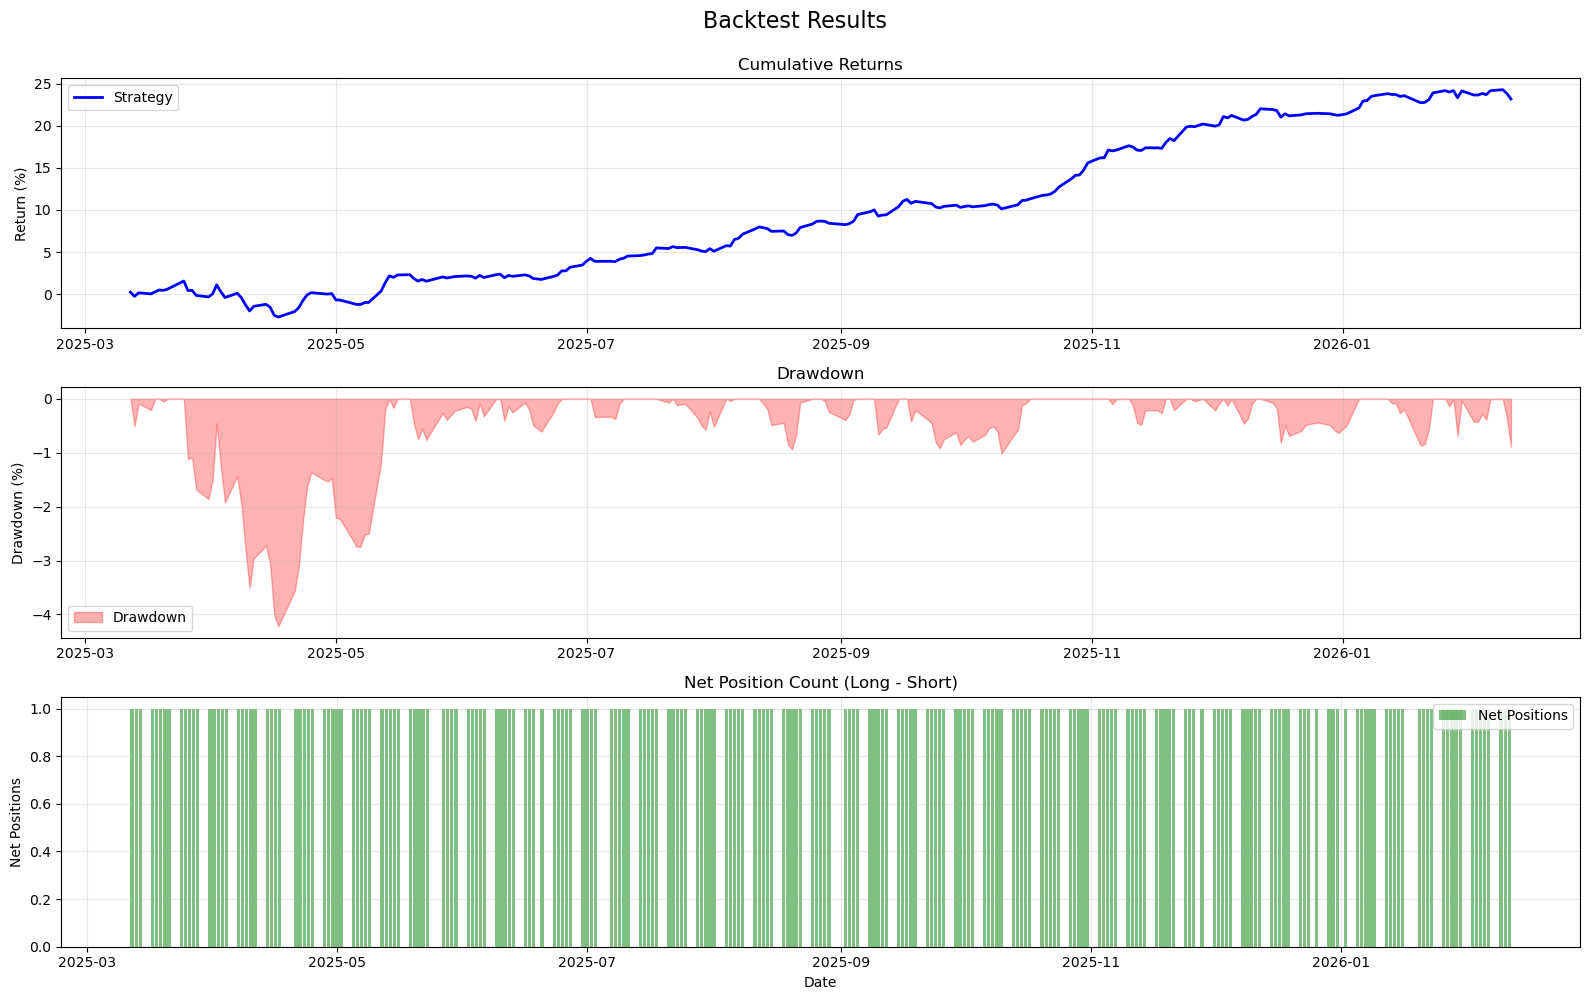

In [4]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
result, backtest = quick_start_portfolio(tickers, days=365)
plot_backtest_results(backtest)

EXAMPLE 1: SINGLE STOCK ANALYSIS

Analyzing AAPL...
✅ Fetched 251 days of data

📊 Alpha Signal Summary:
--------------------------------------------------------------------------------
                 close  component_1  component_2  volume_rank     alpha
Date                                                                   
2026-01-29  258.038544    -0.957493    -0.477100     0.879310  0.168103
2026-01-30  259.237427    -0.400162    -0.502061     0.939655  0.211207
2026-02-02  269.757599    -3.100024    -0.914897     0.870690  0.025862
2026-02-03  269.228088    -2.526279     0.124114     0.793103  0.107759
2026-02-04  276.231506    -3.954520    -0.261255     0.905172  0.017241
2026-02-05  275.652069    -1.258571     0.145136     0.543103  0.275862
2026-02-06  277.859985    -2.027855     0.402010     0.431034  0.250000
2026-02-09  274.619995     0.321397     0.101544     0.280172  0.659483
2026-02-10  273.679993     0.382027     0.390953     0.073276  0.620690
2026-02-11  275.500000 

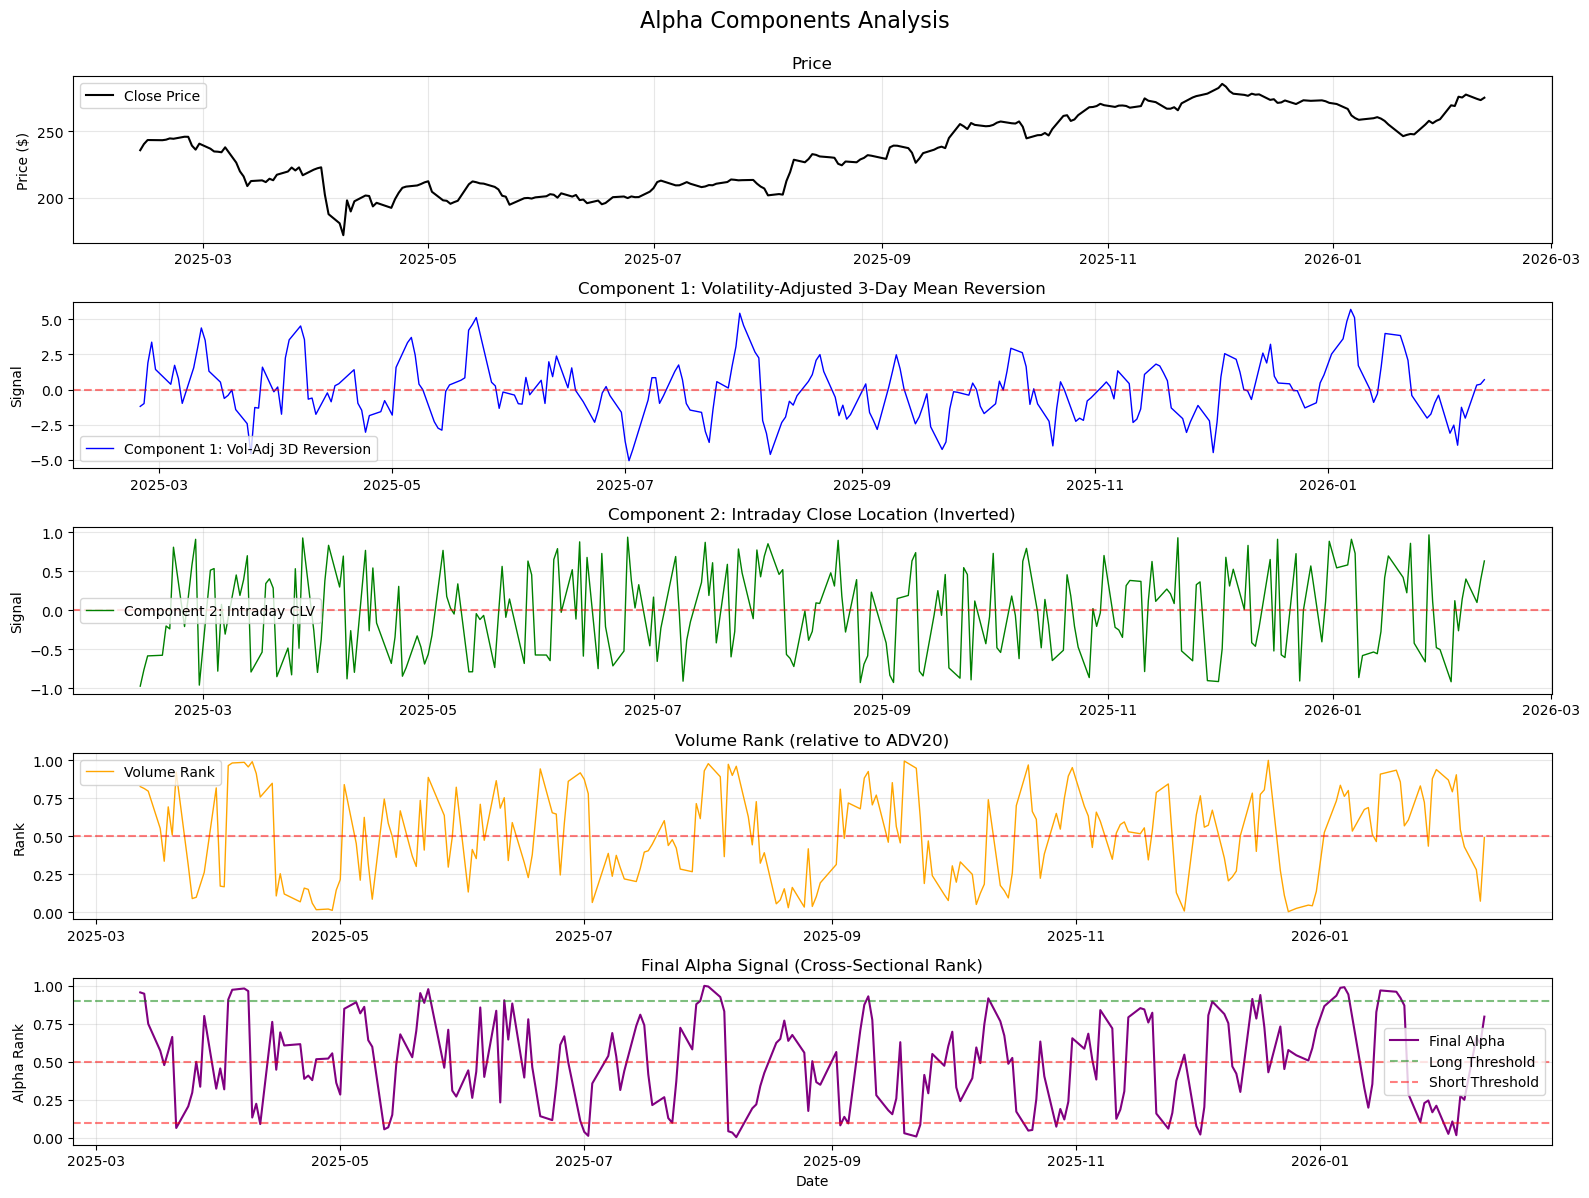

EXAMPLE 2: MULTI-STOCK PORTFOLIO ANALYSIS

📥 Fetching data for 25 stocks from 2025-02-12 to 2026-02-12...
✅ Successfully fetched data for 25 stocks
📅 Date range: 2025-02-12 to 2026-02-11
📊 Total observations: 6,275

🧮 Calculating alpha signals...
✅ Alpha calculation complete!

📊 Sample Alpha Signals (latest date):
--------------------------------------------------------------------------------
             close  alpha
ticker                   
NKE      62.349998   1.00
BAC      53.849998   0.96
MS      176.679993   0.92
WFC      88.949997   0.88
GOOGL   310.959991   0.84
MCD     323.209991   0.80
AMZN    204.080002   0.76
ABBV    220.889999   0.72
TMO     527.169983   0.68
AAPL    275.500000   0.64

🔄 Running backtest...
   Long threshold: top 10% (alpha >= 0.9)
   Short threshold: bottom 10% (alpha <= 0.1)
   Holding period: 1 day(s)

📈 BACKTEST PERFORMANCE:
Total Return..................                1.84%
Annual Return.................                2.00%
Annual Volatility......

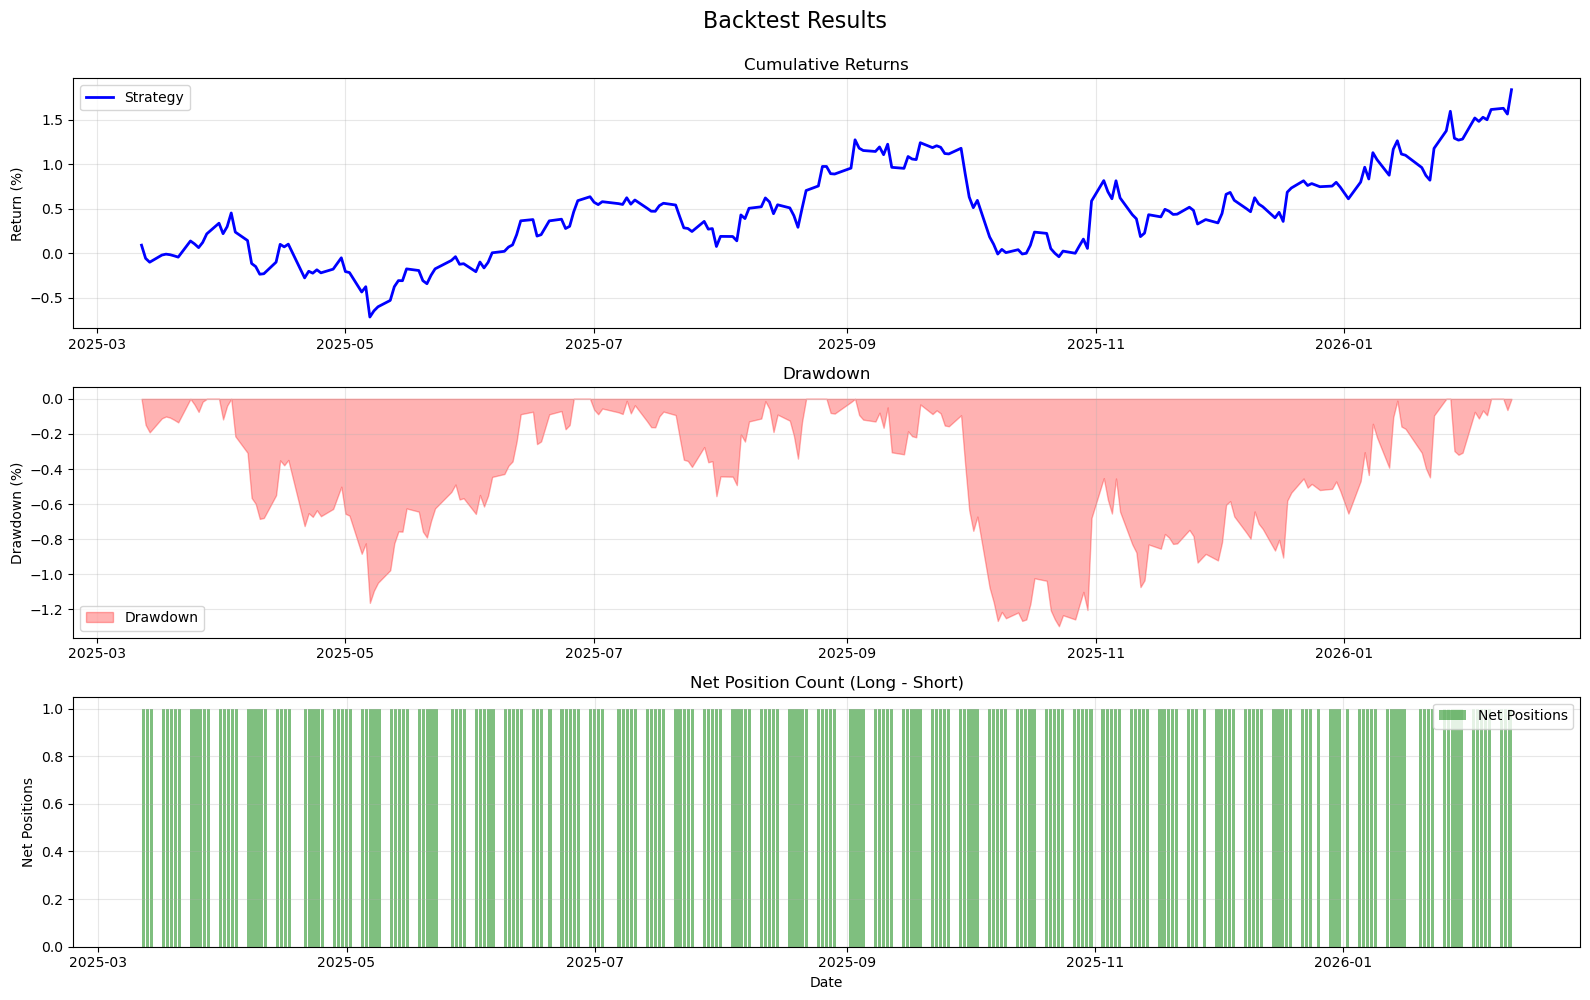

📊 Plotting component analysis for AAPL...


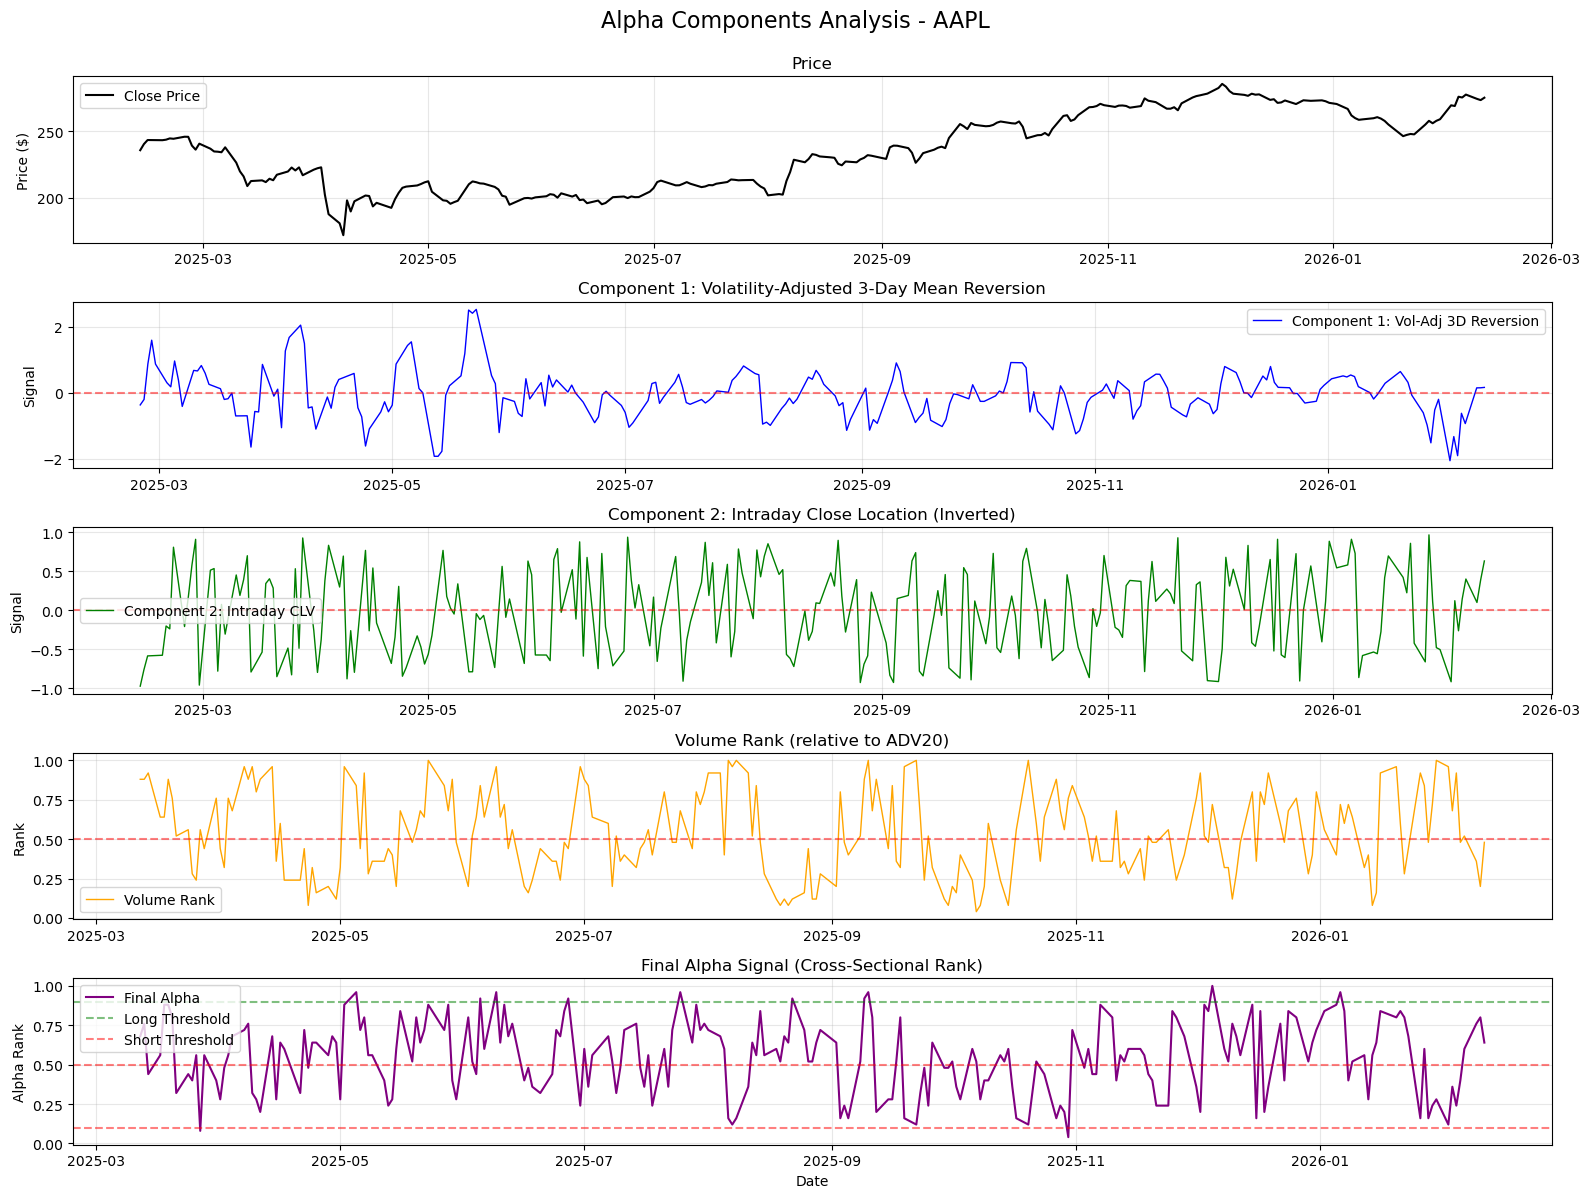

In [6]:
 # Single stock with full analysis
result = example_single_stock()
   # Multi-stock with backtesting
result, backtest = example_multiple_stocks()


## 4️⃣  CUSTOM ANALYSIS:

In [7]:
# Fetch your own data
data = fetch_stock_data(['AAPL', 'MSFT'], '2023-01-01', '2024-01-01')
# Calculate alpha
result = calculate_alpha(data, cross_sectional=True)
# Backtest
backtest = backtest_alpha(result, holding_period=1)
# Get metrics
metrics = calculate_performance_metrics(backtest)
print(metrics)

📥 Fetching data for 2 stocks from 2023-01-01 to 2024-01-01...
✅ Successfully fetched data for 2 stocks
📅 Date range: 2023-01-03 to 2023-12-29
📊 Total observations: 500

🔄 Running backtest...
   Long threshold: top 10% (alpha >= 0.9)
   Short threshold: bottom 10% (alpha <= 0.1)
   Holding period: 1 day(s)

{'Total Return': '49.98%', 'Annual Return': '55.61%', 'Annual Volatility': '10.69%', 'Sharpe Ratio': '5.20', 'Max Drawdown': '-5.89%', 'Win Rate': '58.44%', 'Total Days': 231, 'Avg Daily Return': '0.1779%', '% Days Long Bias': '100.0%', '% Days Short Bias': '0.0%'}


## 📚 KEY FUNCTIONS:

In [9]:

calculate_alpha(df, cross_sectional=False)
## Main alpha calculation function
backtest_alpha(df, holding_period=1, long_percentile=0.9, short_percentile=0.1)
## Backtest the strategy
calculate_performance_metrics(daily_returns)
## Get performance statistics
plot_alpha_components(data, ticker=None)
## Visualize alpha components
plot_backtest_results(daily_returns)
## Visualize backtest performance

NameError: name 'df' is not defined